https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch

# preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from msi import LikelihoodFlow
from msi.flow_conductor import architecture
from msi.utils import input_output, plotting
from msfm.utils import prior, parameters, files, logger, cross_statistics

24-01-23 07:06:27   imports.py INF   Setting up healpy to run on 256 CPUs 


# load the summary statistics

### v6

In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/DESY3/v6/linear_bias"
out_dir = "/pscratch/sd/a/athomsen/run_files/v6"

pca_components = 10

# lensing only
params = ["Om", "s8", "w0", "Aia", "n_Aia"]
with_lensing = True
with_clustering = False
with_cross_z = True
with_cross_probe = False

# # clustering only
# params = ["Om", "s8", "w0", "bg", "n_bg"]
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# with_cross_probe = False

# # combined probes
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# with_lensing = True
# with_clustering = True
# with_cross_z = True
# with_cross_probe = True

label = f"lensing={with_lensing},clustering={with_clustering},cross_z={with_cross_z},cross_probe={with_cross_probe},pca={pca_components}_flow"

bin_indices, bin_names = cross_statistics.get_cross_bin_indices(
        with_lensing=with_lensing,
        with_clustering=with_clustering,
        with_cross_z=with_cross_z,
        with_cross_probe=with_cross_probe,
)

#### power spectra

In [4]:
file_dict = input_output.load_human_summaries(os.path.join(base_dir, "cls"), "cls")

24-01-23 07:06:29 input_output INF   Array shapes: 
24-01-23 07:06:29 input_output INF   fiducial/cls       = (2400, 32, 36) 
24-01-23 07:06:29 input_output INF   fiducial/i_example = (2400,) 
24-01-23 07:06:29 input_output INF   fiducial/i_noise   = (2400,) 
24-01-23 07:06:30 input_output INF   grid/cls           = (1500, 48, 32, 36) 
24-01-23 07:06:30 input_output INF   grid/cosmo         = (1500, 48, 10) 
24-01-23 07:06:30 input_output INF   grid/i_example     = (1500, 48) 
24-01-23 07:06:30 input_output INF   grid/i_noise       = (1500, 48) 
24-01-23 07:06:30 input_output INF   grid/i_sobol       = (1500, 48) 


In [5]:
file_dict.keys()

dict_keys(['fiducial/cls', 'fiducial/i_example', 'fiducial/i_noise', 'grid/cls', 'grid/cosmo', 'grid/i_example', 'grid/i_noise', 'grid/i_sobol'])

24-01-23 07:06:30 input_output INF   Array shapes: 
24-01-23 07:06:30 input_output INF   fiducial/cls       = (2400, 32, 36) 
24-01-23 07:06:30 input_output INF   fiducial/i_example = (2400,) 
24-01-23 07:06:30 input_output INF   fiducial/i_noise   = (2400,) 
24-01-23 07:06:30 input_output INF   grid/cls           = (1500, 48, 32, 36) 
24-01-23 07:06:30 input_output INF   grid/cosmo         = (1500, 48, 10) 
24-01-23 07:06:30 input_output INF   grid/i_example     = (1500, 48) 
24-01-23 07:06:30 input_output INF   grid/i_noise       = (1500, 48) 
24-01-23 07:06:30 input_output INF   grid/i_sobol       = (1500, 48) 
24-01-23 07:06:30 input_output INF   Using the bin indices [0, 1, 2, 3, 8, 9, 10, 15, 16, 21] 
24-01-23 07:06:30 input_output INF   With names ['bin_0x0' 'bin_0x1' 'bin_0x2' 'bin_0x3' 'bin_1x1' 'bin_1x2' 'bin_1x3'
 'bin_2x2' 'bin_2x3' 'bin_3x3'] 


24-01-23 07:06:30 input_output INF   Shapes after selection 
24-01-23 07:06:30 input_output INF   fidu_cls = (2400, 32, 10) 
24-0

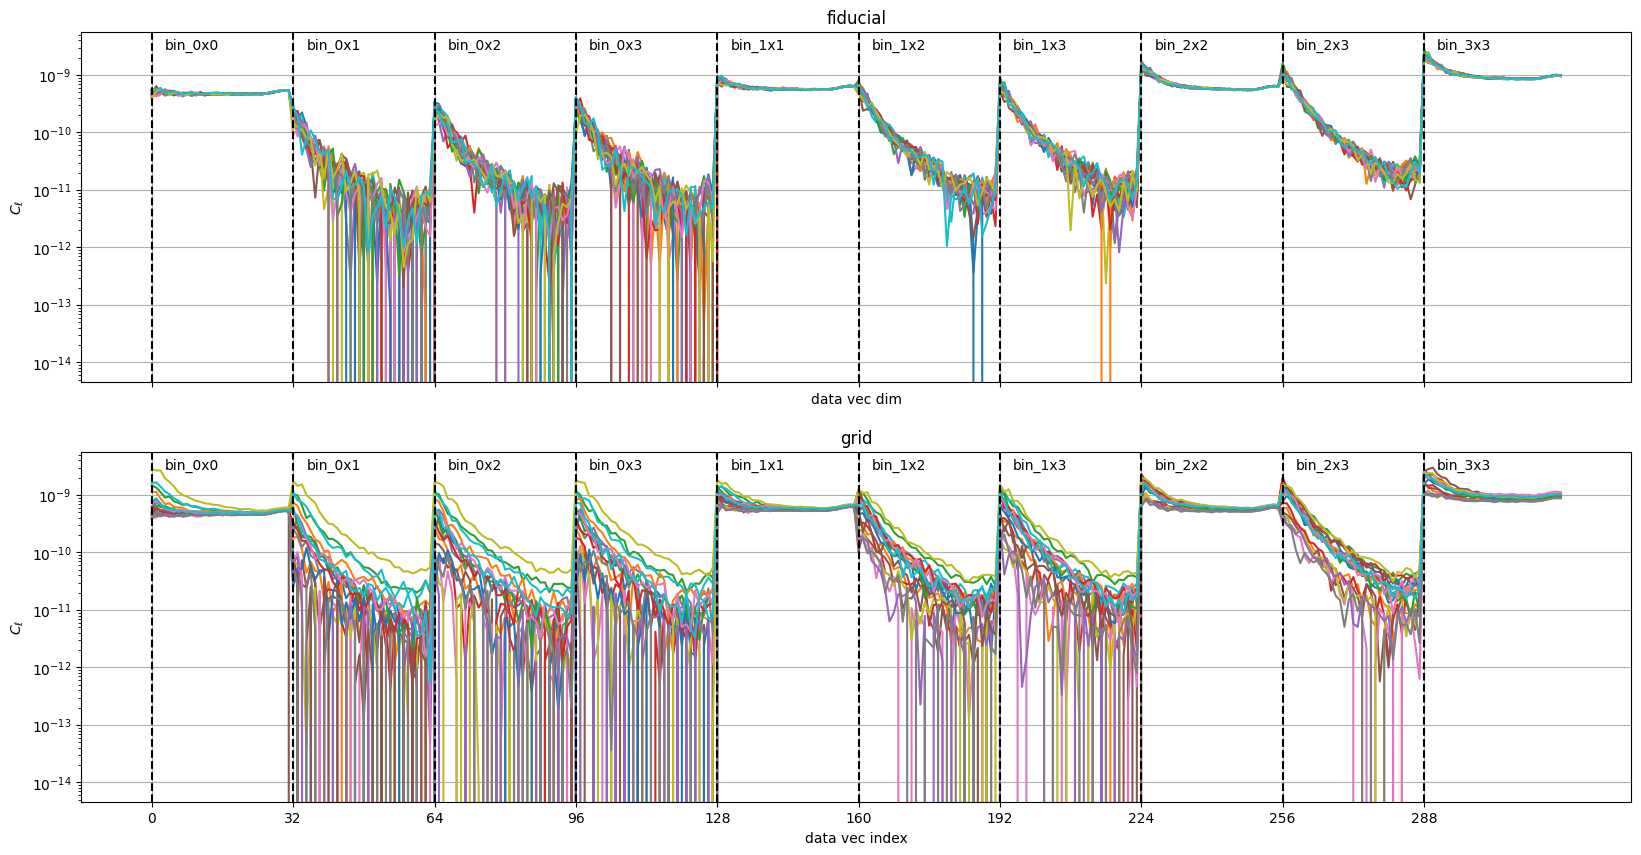

In [6]:
fidu_summs, grid_summs, grid_cosmos = input_output.get_reshaped_human_summaries(
    os.path.join(base_dir, "cls"), 
    "cls", 
    # file
    file_label=None,
    # configuration
    conf=conf, 
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_cross_probe=with_cross_probe,
    # additional preprocessing
    apply_log=False,
    pca_components=pca_components,
)

# TODO fix this in the cls file generation
grid_cosmos = grid_cosmos[:,0,:]

out_dir = os.path.join(out_dir, "cls") if (os.path.basename(out_dir) != "cls") else out_dir

#### peaks

In [7]:
# fidu_summs, grid_summs, grid_cosmos = input_output.get_reshaped_human_summaries(
#     os.path.join(base_dir, "peaks"), 
#     "peaks", 
#     # file
#     file_label=None,
#     # configuration
#     conf=conf, 
#     params=params,
#     # selection
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     with_cross_z=with_cross_z,
#     with_cross_probe=with_cross_probe,
#     # additional preprocessing
#     apply_log=False,
#     pca_components=pca_components,
# )

# out_dir = os.path.join(out_dir, "peaks") if (os.path.basename(out_dir) != "peaks") else out_dir

### general

In [8]:
os.makedirs(out_dir, exist_ok=True)

### observation

In [9]:
i_obs = 0
# i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))

print(f"Using the example index {i_obs}")
obs_pred = fidu_summs[i_obs]

Using the example index 0


# likelihood Flow $p(x|\theta)$

In [10]:
# input dimensions
x_dim = grid_summs.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 64

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=5,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 20,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

flow = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    label=label
)

24-01-23 07:06:35 likelihood_f INF   Initialized the normalizing flow 
24-01-23 07:06:35 likelihood_f INF   Running on device cuda with default float torch.float32 


### training

 27%|███████▌                    |   | 27/100 [02:54<07:28,  6.14s/it]        lr: 8.31E-04, train: 0.85, vali: 0.91:  24-01-23 07:09:37   pytorch.py INF   <All keys matched successfully> 
24-01-23 07:09:37   pytorch.py INF   Restored the weights from the best epoch (vali_loss = 0.75) 
24-01-23 07:09:37 likelihood_f INF   Stopping early after 27 epochs 
 27%|███████▌                    |   | 27/100 [03:00<08:08,  6.69s/it]        lr: 8.31E-04, train: 0.85, vali: 0.91: 
24-01-23 07:09:37 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v6/cls/modellensing=True,clustering=False,cross_z=True,cross_probe=False,pca=10_flow.pt 


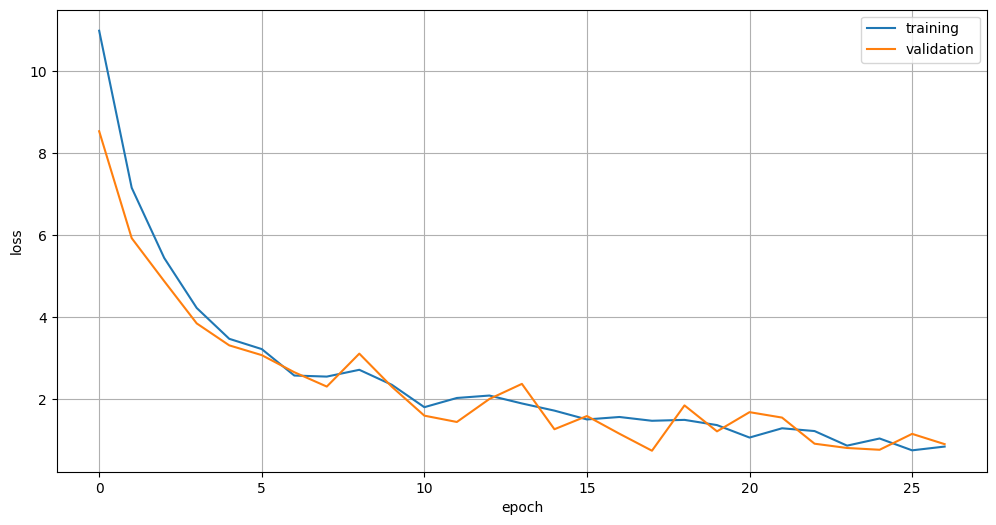

In [11]:
flow.fit(
    x=grid_summs,
    theta=grid_cosmos,
    n_epochs=100,
    # dataset
    batch_size=1024,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-3,
    weight_decay=0.0,
    clip_by_global_norm=100.0,
    learning_rate_min=1e-6,
    # early stopping
    n_patience_epochs=10,
    min_delta=0.0,
    save_model=True,
)

### MCMC

In [12]:
posterior_samples = flow.sample_posterior(
    obs_pred,
)

24-01-23 07:09:38      mcmc.py INF   Initial values in prior: True 
24-01-23 07:09:38      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-01-23 07:09:49      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:45<00:00, 11.08it/s]

24-01-23 07:10:34      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v6/cls/chain_lensing=True,clustering=False,cross_z=True,cross_probe=False,pca=10_flow.npy 


### plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-01-23 07:10:39  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v6/cls/contours_lensing=True,clustering=False,cross_z=True,cross_probe=False,pca=10_flow.png 


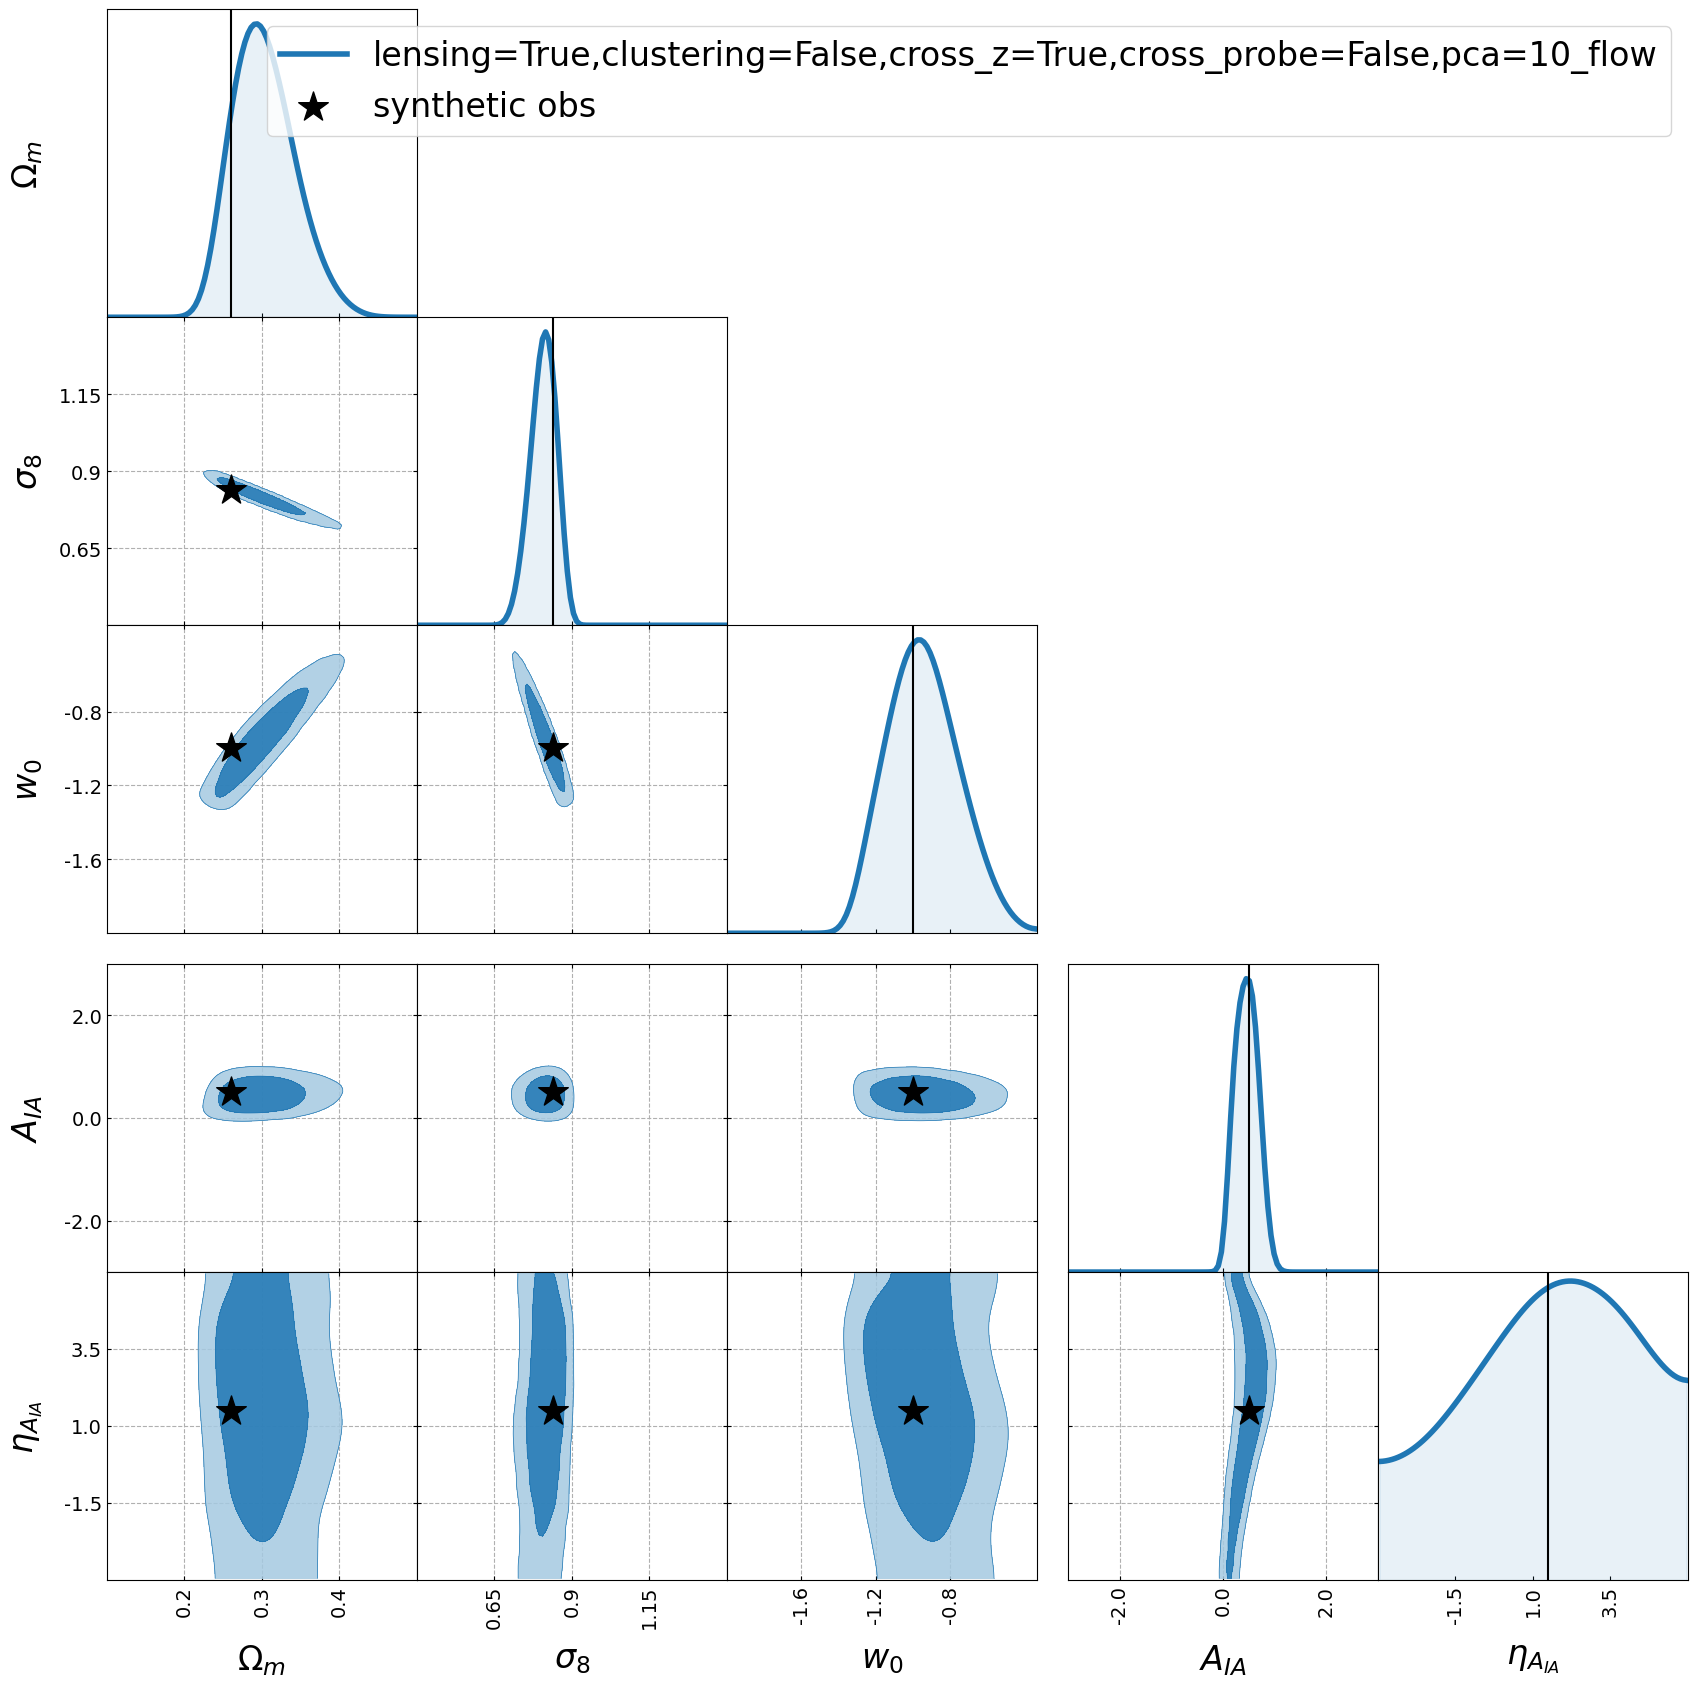

In [13]:
flow.plot_contours(
    posterior_samples,
)